In [10]:
# !pip install matplotlib 
#!pip install seaborn

# EDA

## Loading Court cases FIle

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import ast

In [6]:
df = pd.read_csv('../Data/Processed/court_cases.csv', parse_dates=['Date'])
df.head()


,Case_Number,Coram,Judge,Date,Tribunal_Court,Plaintiff_Name,Defendant_Name,Combined_Facts,Combined_Issue,Combined_Rule,Combined_Application,plaintiff_label,defendant_label
0,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Holdings Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...","['Whether, based on the pre-2003 employment co...","['Under employment and company law, the obliga...",['ABB Holdings Pte Ltd issued and administered...,Claim Dismissed,Liable
1,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Installation Materials (East Asia) Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...",['Whether the pre-2003 conduct of Sher Hock Gu...,['Company officers and senior managers must av...,['ABB Installation Materials (East Asia) Pte L...,Claim Dismissed,Liable
2,Suit 798/2007,Judith Prakash J,Judith Prakash,2009-07-06,High Court,ABB Industry Pte Ltd,Sher Hock Guan Charles,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '19...","['Whether, before and up to February 2003, the...",['Senior managers responsible for a business a...,['While serving as General Manager and Vice-Pr...,Claim Allowed,Liable
3,Suit No 477 of 2012; Suit No 1015 of 2012; Reg...,George Wei JC,George Wei,2014-02-14,High Court,Airtrust (Singapore) Pte Ltd (AT) – Suit No 47...,Kao Chai-Chau Linda,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '20...","['Whether, in Suit No 477 of 2012, losses to A...",['Where multiple persons are each legally resp...,"['Airtrust (Singapore) Pte Ltd, through the de...",Claim Allowed,Liable
4,Suit No 477 of 2012; Suit No 1015 of 2012; Reg...,George Wei JC,George Wei,2014-02-14,High Court,Airtrust (Singapore) Pte Ltd (AT) – Suit No 47...,Estate of Peter Fong,"[[{'Fact_Type': 'PARTY_INFO', 'Fact_Date': '20...","['Whether, in Suit No 477 of 2012, losses to A...",['Where multiple persons are each legally resp...,"['Airtrust (Singapore) Pte Ltd, through the de...",Claim Allowed,Liable


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 424 entries, 0 to 423
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Case_Number           424 non-null    str           
 1   Coram                 424 non-null    str           
 2   Judge                 424 non-null    str           
 3   Date                  424 non-null    datetime64[us]
 4   Tribunal_Court        424 non-null    str           
 5   Plaintiff_Name        424 non-null    str           
 6   Defendant_Name        424 non-null    str           
 7   Combined_Facts        424 non-null    str           
 8   Combined_Issue        424 non-null    str           
 9   Combined_Rule         424 non-null    str           
 10  Combined_Application  424 non-null    str           
 11  plaintiff_label       422 non-null    str           
 12  defendant_label       424 non-null    str           
dtypes: datetime64[us](1), str(12)
m

In [8]:
df.isnull().sum()

Case_Number             0
Coram                   0
Judge                   0
Date                    0
Tribunal_Court          0
Plaintiff_Name          0
Defendant_Name          0
Combined_Facts          0
Combined_Issue          0
Combined_Rule           0
Combined_Application    0
plaintiff_label         2
defendant_label         0
dtype: int64

In [9]:
# Set standard plotting style for beautiful charts
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Convert the Date column to proper datetime objects and extract the Year
df['Date'] = pd.to_datetime(df['Date'])
df['Year'] = df['Date'].dt.year

# Let's see the shape of what we are working with
print(f"Dataset contains {df.shape[0]} case combinations and {df.shape[1]} columns.")

Dataset contains 424 case combinations and 14 columns.


In [10]:
cat_cols = ["Tribunal_Court", "plaintiff_label", "defendant_label"]
for col in cat_cols:
    print(f"\n--- {col} ---")
    vc = df[col].value_counts()
    print(vc.to_string())
 
print(f"\n--- Unique Judges ({df['Judge'].nunique()}) ---")
print(df["Judge"].value_counts().head(15).to_string())


--- Tribunal_Court ---
Tribunal_Court
High Court                                                         140
General Division of the High Court of the Republic of Singapore    109
High Court of the Republic of Singapore                             77
High Court of Singapore                                             34
Court of Appeal of the Republic of Singapore                        25
Court of Appeal                                                     20
General Division of the High Court of Singapore                     11
Singapore International Commercial Court                             5
Appellate Division of the High Court of Singapore                    3

--- plaintiff_label ---
plaintiff_label
Claim Allowed            250
Claim Dismissed          163
Claim Allowed In Part      9

--- defendant_label ---
defendant_label
Not Liable    213
Liable        211

--- Unique Judges (60) ---
Judge
Lai Siu Chiu           24
Mohamed Faizal         24
Kannan Ramesh          23
Hri K

In [11]:
print(f"Date range : {df['Date'].min().date()}  →  {df['Date'].max().date()}")
print(f"Cases by year:\n{df['Date'].dt.year.value_counts().sort_index().to_string()}")

Date range : 2000-07-03  →  2025-08-06
Cases by year:
Date
2000     4
2001     5
2002     1
2003    39
2004    26
2005     2
2006     9
2007    12
2008     4
2009     3
2010     8
2011     3
2012     4
2013    29
2014    18
2015     5
2016    25
2017    27
2018    20
2019    26
2020    19
2021    21
2022    26
2023     4
2024    41
2025    43


In [12]:
text_cols = ["Combined_Facts", "Combined_Issue", "Combined_Rule", "Combined_Application"]
for col in text_cols:
    lengths = df[col].str.len()
    print(f"\n{col}:")
    print(f"  min={lengths.min():,}  median={lengths.median():,.0f}  "
          f"mean={lengths.mean():,.0f}  max={lengths.max():,}")


Combined_Facts:
  min=428  median=7,158  mean=8,779  max=36,629

Combined_Issue:
  min=275  median=493  mean=512  max=1,262

Combined_Rule:
  min=334  median=722  mean=784  max=2,016

Combined_Application:
  min=353  median=1,192  mean=1,319  max=4,088


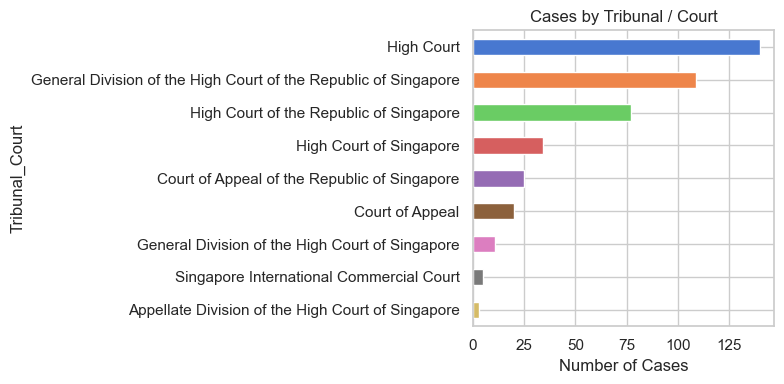

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = df["Tribunal_Court"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(vc)))
ax.set_title("Cases by Tribunal / Court")
ax.set_xlabel("Number of Cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()
# do data cleaning on this

In [14]:
court_mapping = {
    "High Court": "High Court of Singapore",
    "High Court of the Republic of Singapore": "High Court of Singapore",
    "High Court of Singapore": "High Court of Singapore",

    "General Division of the High Court of the Republic of Singapore": "General Division of the High Court of Singapore",
    "General Division of the High Court of Singapore": "General Division of the High Court of Singapore",

    "Court of Appeal": "Court of Appeal",
    "Court of Appeal of the Republic of Singapore": "Court of Appeal",

    "Singapore International Commercial Court": "Singapore International Commercial Court",

    "Appellate Division of the High Court of Singapore": "Appellate Division of the High Court of Singapore",
}

df["Tribunal_Court"] = df["Tribunal_Court"].map(court_mapping).fillna(df["Tribunal_Court"])


In [15]:
print(df["Tribunal_Court"].value_counts())


Tribunal_Court
High Court of Singapore                              251
General Division of the High Court of Singapore      120
Court of Appeal                                       45
Singapore International Commercial Court               5
Appellate Division of the High Court of Singapore      3
Name: count, dtype: int64


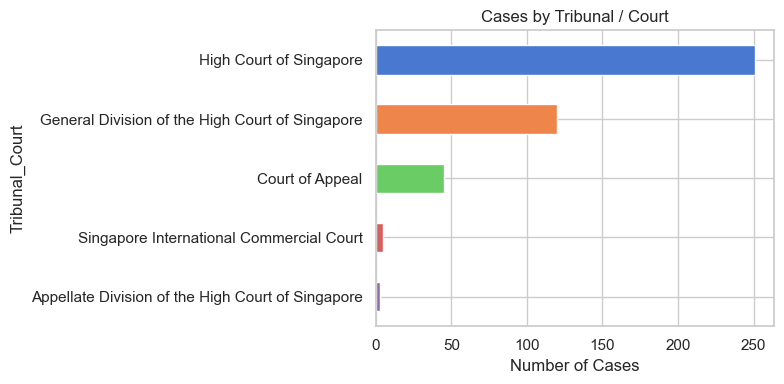

In [16]:
fig, ax = plt.subplots(figsize=(8, 4))
vc = df["Tribunal_Court"].value_counts()
vc.plot(kind="barh", ax=ax, color=sns.color_palette("muted", len(vc)))
ax.set_title("Cases by Tribunal / Court")
ax.set_xlabel("Number of Cases")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_36884\2196680752.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='defendant_label', palette='viridis')


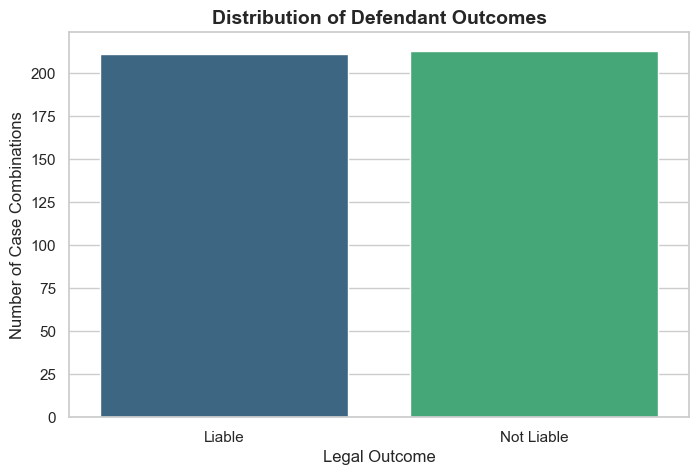

In [15]:
# Distribution of Case Outcomes
plt.figure(figsize=(8, 5))
# Using defendant_label to see how often they are 'Liable' vs 'Not Liable'
sns.countplot(data=df, x='defendant_label', palette='viridis')
plt.title('Distribution of Defendant Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Legal Outcome')
plt.ylabel('Number of Case Combinations')
plt.show()



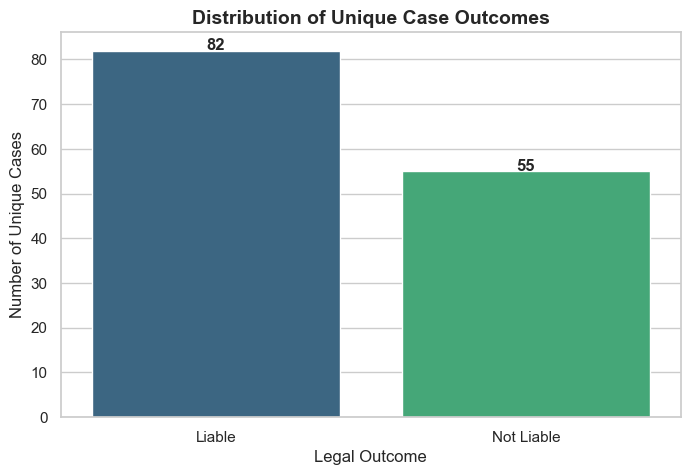

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Group by Case_Number to get the outcome for each unique case
# We take the 'first' label since the outcome is the same for all rows in a case
unique_cases = df.groupby('Case_Number')['defendant_label'].first().reset_index()

# 2. Plot the Distribution
plt.figure(figsize=(8, 5))
sns.countplot(data=unique_cases, x='defendant_label', palette='viridis', hue='defendant_label', legend=False)

plt.title('Distribution of Unique Case Outcomes', fontsize=14, fontweight='bold')
plt.xlabel('Legal Outcome')
plt.ylabel('Number of Unique Cases')

# Add counts on top of bars for clarity
for i, count in enumerate(unique_cases['defendant_label'].value_counts().sort_index()):
    plt.text(i, count + 0.1, str(count), ha='center', fontweight='bold')

plt.show()

In [19]:
# Ensure Date is datetime type for sorting
df['Date'] = pd.to_datetime(df['Date'])

# Group by Case_Number to find the earliest date per case, then sort
cases = df.groupby('Case_Number')['Date'].min().sort_values().reset_index()

# Calculate split indices (70% Train, 15% Val, 15% Test)
n_cases = len(cases)
train_end = int(n_cases * 0.7)
val_end = int(n_cases * 0.85)

# Extract the Case_Numbers for each split
train_case_ids = cases.iloc[:train_end]['Case_Number']
val_case_ids = cases.iloc[train_end:val_end]['Case_Number']
test_case_ids = cases.iloc[val_end:]['Case_Number']

# Map the isolated Case_Numbers back to the main DataFrame
# Using .copy() prevents SettingWithCopy warnings later
train_df = df[df['Case_Number'].isin(train_case_ids)].copy()
val_df = df[df['Case_Number'].isin(val_case_ids)].copy()
test_df = df[df['Case_Number'].isin(test_case_ids)].copy()

print(f"Train: {len(train_df)} rows | Val: {len(val_df)} rows | Test: {len(test_df)} rows")

# 1. Create a combined lookup for all cases and their split assignment
train_df['Split'] = 'Train'
val_df['Split'] = 'Val'
test_df['Split'] = 'Test'

# 2. Combine and get the earliest date per unique Case_Number
all_splits = pd.concat([train_df, val_df, test_df])
case_timeline = all_splits.groupby('Case_Number').agg({
    'Date': 'min', 
    'Split': 'first'
}).reset_index()

# 3. Sort by Date to ensure the plot respects time
case_timeline = case_timeline.sort_values('Date')

Train: 291 rows | Val: 49 rows | Test: 84 rows


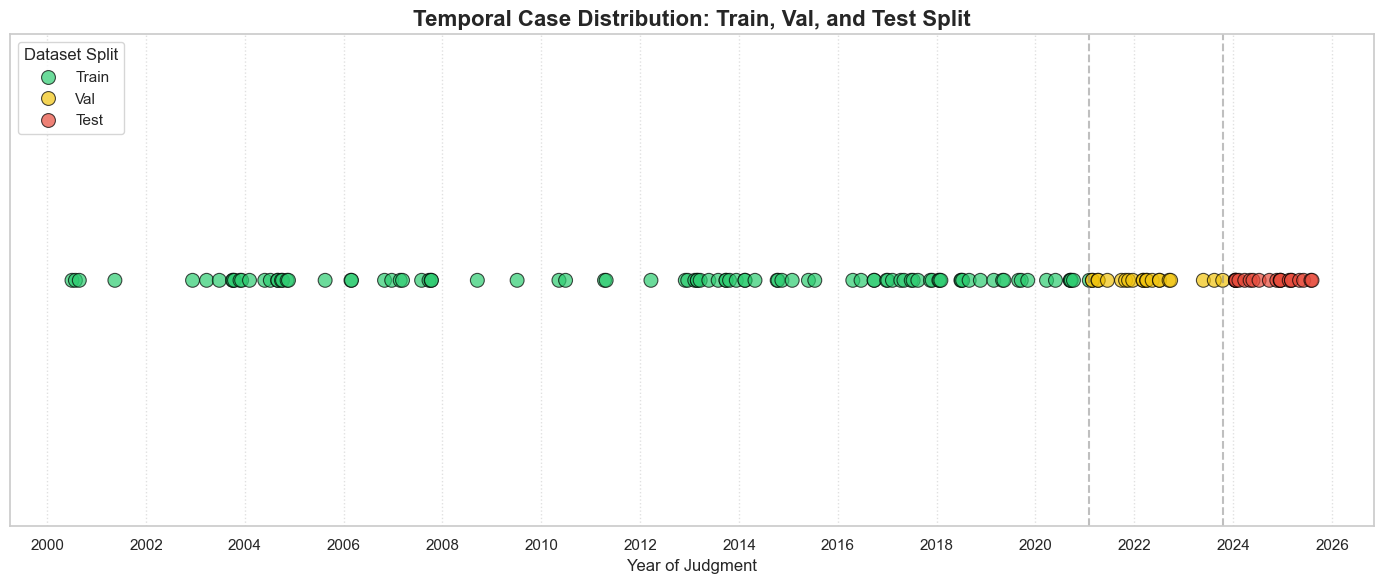

In [20]:
plt.figure(figsize=(14, 6))

# Define colors for each split
colors = {'Train': '#2ecc71', 'Val': '#f1c40f', 'Test': '#e74c3c'}

# Create the scatter plot
sns.scatterplot(
    data=case_timeline, 
    x='Date', 
    y=[1] * len(case_timeline), # Keep all points on one horizontal line
    hue='Split', 
    palette=colors, 
    s=100, 
    edgecolor='black', 
    alpha=0.7
)

# Add vertical lines at the split boundaries
train_max = case_timeline[case_timeline['Split'] == 'Train']['Date'].max()
val_max = case_timeline[case_timeline['Split'] == 'Val']['Date'].max()

plt.axvline(x=train_max, color='gray', linestyle='--', alpha=0.5)
plt.axvline(x=val_max, color='gray', linestyle='--', alpha=0.5)

# Formatting
plt.title('Temporal Case Distribution: Train, Val, and Test Split', fontsize=16, fontweight='bold')
plt.xlabel('Year of Judgment', fontsize=12)
plt.yticks([]) # Hide the Y-axis as it has no meaning here
plt.grid(axis='x', linestyle=':', alpha=0.6)

# Format the X-axis to show years clearly
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator(2)) # Show every 2 years

plt.legend(title='Dataset Split', loc='upper left')
plt.tight_layout()
plt.show()

In [22]:
# 1. Update the timeline dataframe to include the label
case_timeline = all_splits.groupby('Case_Number').agg({
    'Date': 'min', 
    'Split': 'first',
    'defendant_label': 'first'  # We pull the label into our unique case list
}).reset_index()

# 2. Print the detailed temporal and label breakdown
print("==================================================")
print("       TEMPORAL SPLIT & LABEL DISTRIBUTION")
print("==================================================")

for split in ['Train', 'Val', 'Test']:
    subset = case_timeline[case_timeline['Split'] == split]
    label_counts = subset['defendant_label'].value_counts()
    total = len(subset)
    
    print(f"\n[{split} Split]")
    print(f"Range: {subset['Date'].min().date()} to {subset['Date'].max().date()}")
    print(f"Total Cases: {total}")
    
    for label, count in label_counts.items():
        pct = (count / total) * 100
        print(f"  - {label:10}: {count} cases ({pct:.1f}%)")
    print("-" * 40)

       TEMPORAL SPLIT & LABEL DISTRIBUTION

[Train Split]
Range: 2000-07-03 to 2021-02-02
Total Cases: 95
  - Liable    : 55 cases (57.9%)
  - Not Liable: 40 cases (42.1%)
----------------------------------------

[Val Split]
Range: 2021-02-25 to 2023-10-16
Total Cases: 21
  - Liable    : 13 cases (61.9%)
  - Not Liable: 8 cases (38.1%)
----------------------------------------

[Test Split]
Range: 2024-01-18 to 2025-08-06
Total Cases: 21
  - Liable    : 14 cases (66.7%)
  - Not Liable: 7 cases (33.3%)
----------------------------------------


In [21]:
for split in ['Train', 'Val', 'Test']:
    subset = case_timeline[case_timeline['Split'] == split]
    print(f"{split} Range: {subset['Date'].min().date()} to {subset['Date'].max().date()} ({len(subset)} cases)")

Train Range: 2000-07-03 to 2021-02-02 (95 cases)
Val Range: 2021-02-25 to 2023-10-16 (21 cases)
Test Range: 2024-01-18 to 2025-08-06 (21 cases)


C:\Users\User\AppData\Local\Temp\ipykernel_36884\2073473518.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='defendant_label', y='App_WordCount', palette='Set2')


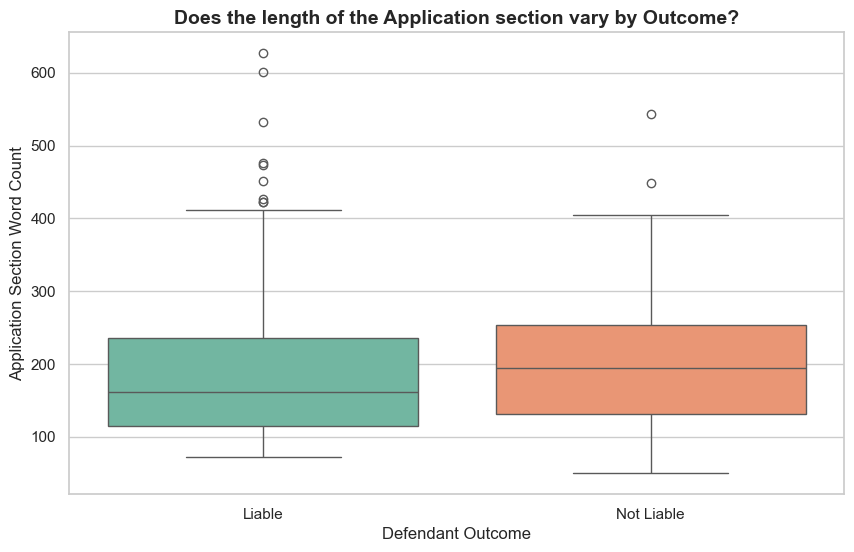

In [23]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='defendant_label', y='App_WordCount', palette='Set2')
plt.title('Does the length of the Application section vary by Outcome?', fontsize=14, fontweight='bold')
plt.xlabel('Defendant Outcome')
plt.ylabel('Application Section Word Count')
plt.show()

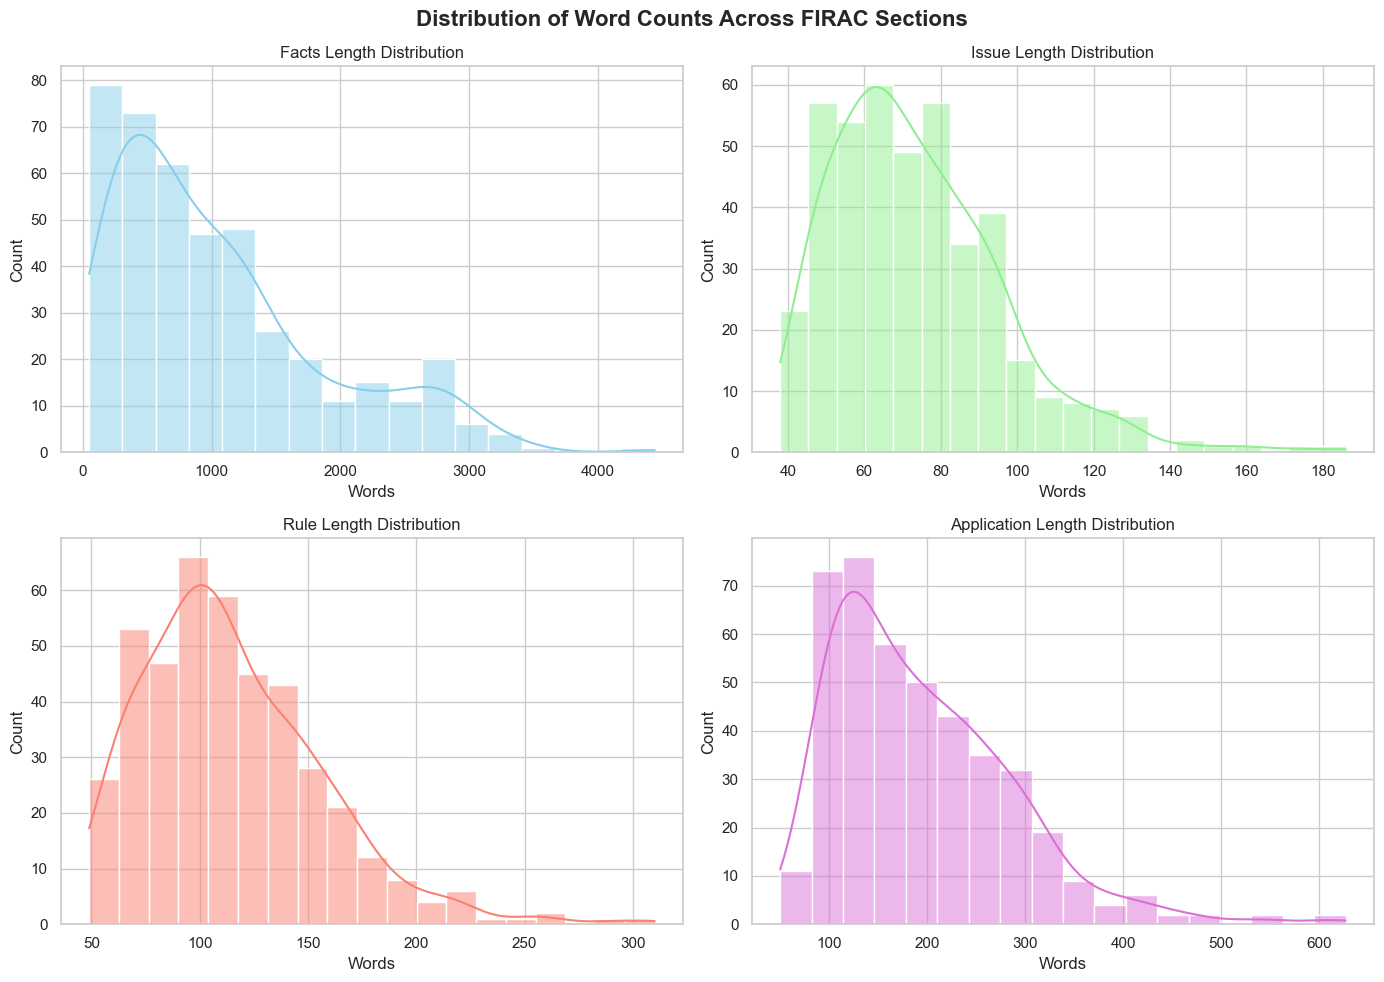

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Word Counts Across FIRAC Sections', fontsize=16, fontweight='bold')

# Plot Facts
sns.histplot(df['Facts_WordCount'], kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Facts Length Distribution')
axes[0, 0].set_xlabel('Words')

# Plot Issue
sns.histplot(df['Issue_WordCount'], kde=True, ax=axes[0, 1], color='lightgreen')
axes[0, 1].set_title('Issue Length Distribution')
axes[0, 1].set_xlabel('Words')

# Plot Rule
sns.histplot(df['Rule_WordCount'], kde=True, ax=axes[1, 0], color='salmon')
axes[1, 0].set_title('Rule Length Distribution')
axes[1, 0].set_xlabel('Words')

# Plot Application
sns.histplot(df['App_WordCount'], kde=True, ax=axes[1, 1], color='orchid')
axes[1, 1].set_title('Application Length Distribution')
axes[1, 1].set_xlabel('Words')

plt.tight_layout()
plt.show()

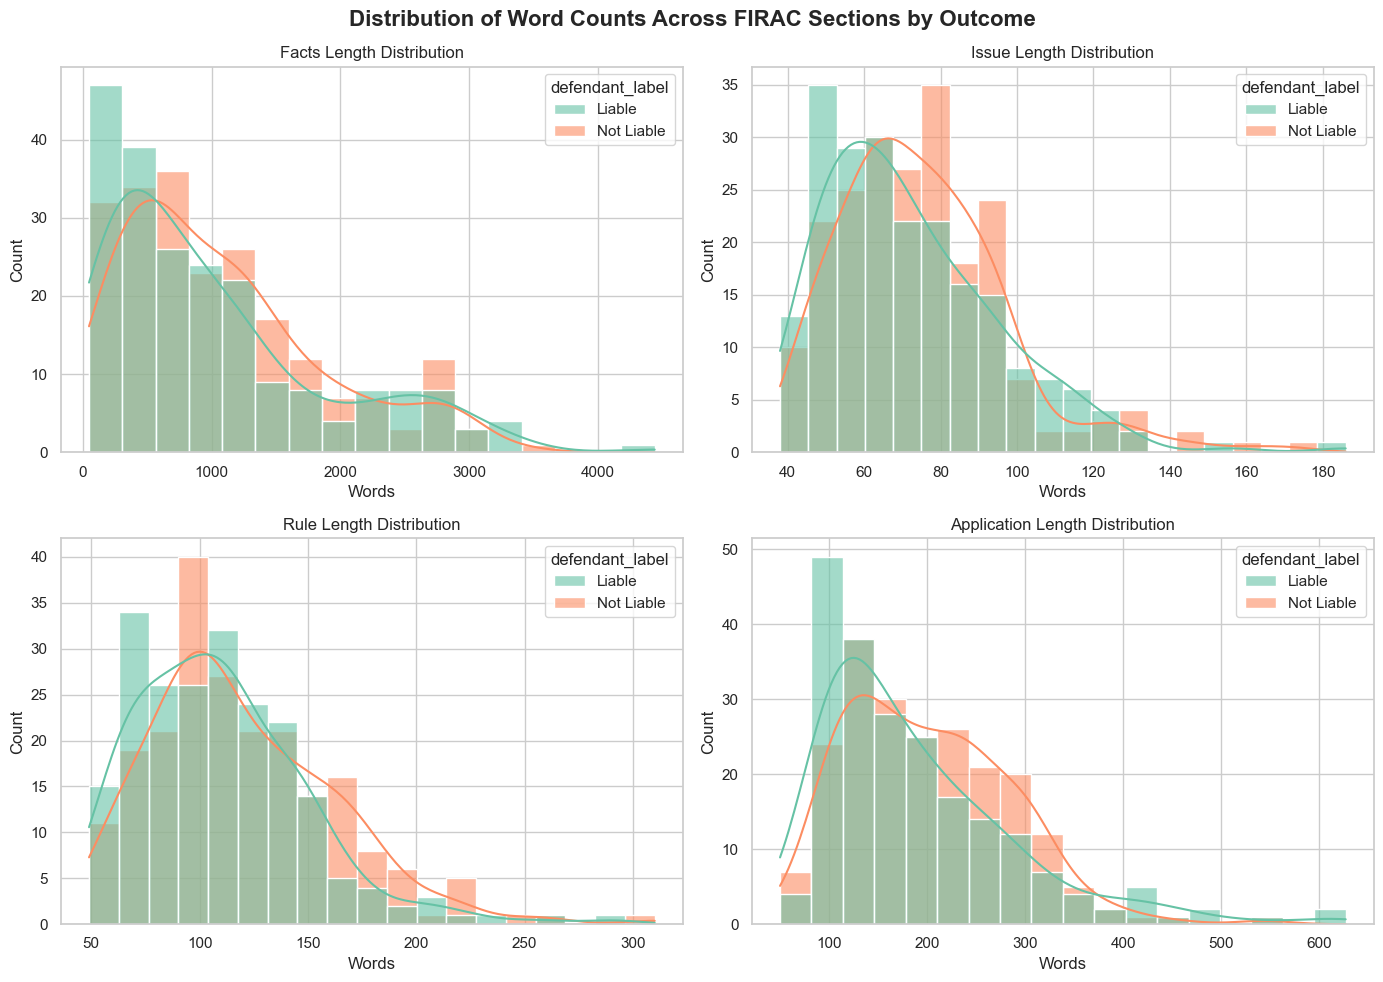

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of Word Counts Across FIRAC Sections by Outcome', fontsize=16, fontweight='bold')

# Plot Facts
sns.histplot(data=df, x='Facts_WordCount', hue='defendant_label', kde=True, ax=axes[0, 0], palette='Set2', alpha=0.6)
axes[0, 0].set_title('Facts Length Distribution')
axes[0, 0].set_xlabel('Words')

# Plot Issue
sns.histplot(data=df, x='Issue_WordCount', hue='defendant_label', kde=True, ax=axes[0, 1], palette='Set2', alpha=0.6)
axes[0, 1].set_title('Issue Length Distribution')
axes[0, 1].set_xlabel('Words')

# Plot Rule
sns.histplot(data=df, x='Rule_WordCount', hue='defendant_label', kde=True, ax=axes[1, 0], palette='Set2', alpha=0.6)
axes[1, 0].set_title('Rule Length Distribution')
axes[1, 0].set_xlabel('Words')

# Plot Application
sns.histplot(data=df, x='App_WordCount', hue='defendant_label', kde=True, ax=axes[1, 1], palette='Set2', alpha=0.6)
axes[1, 1].set_title('Application Length Distribution')
axes[1, 1].set_xlabel('Words')

plt.tight_layout()
plt.show()

--- Tabular Breakdown ---
          Fact_Type Outcome_Label  Count
            CONDUCT        Liable   2105
            CONDUCT    Not Liable   2086
    FINANCIAL_EVENT        Liable   1539
    FINANCIAL_EVENT    Not Liable   1267
     CONTRACT_EVENT    Not Liable    932
      COMMUNICATION    Not Liable    846
     CORPORATE_ROLE        Liable    789
      COMMUNICATION        Liable    715
     CORPORATE_ROLE    Not Liable    664
     CONTRACT_EVENT        Liable    645
           DOCUMENT    Not Liable    518
           DOCUMENT        Liable    504
         PARTY_INFO    Not Liable    457
       BOARD_ACTION    Not Liable    427
         PARTY_INFO        Liable    422
       RELATIONSHIP    Not Liable    295
       BOARD_ACTION        Liable    257
       RELATIONSHIP        Liable    246
RELATED_PARTY_EVENT        Liable    189
RELATED_PARTY_EVENT    Not Liable    118


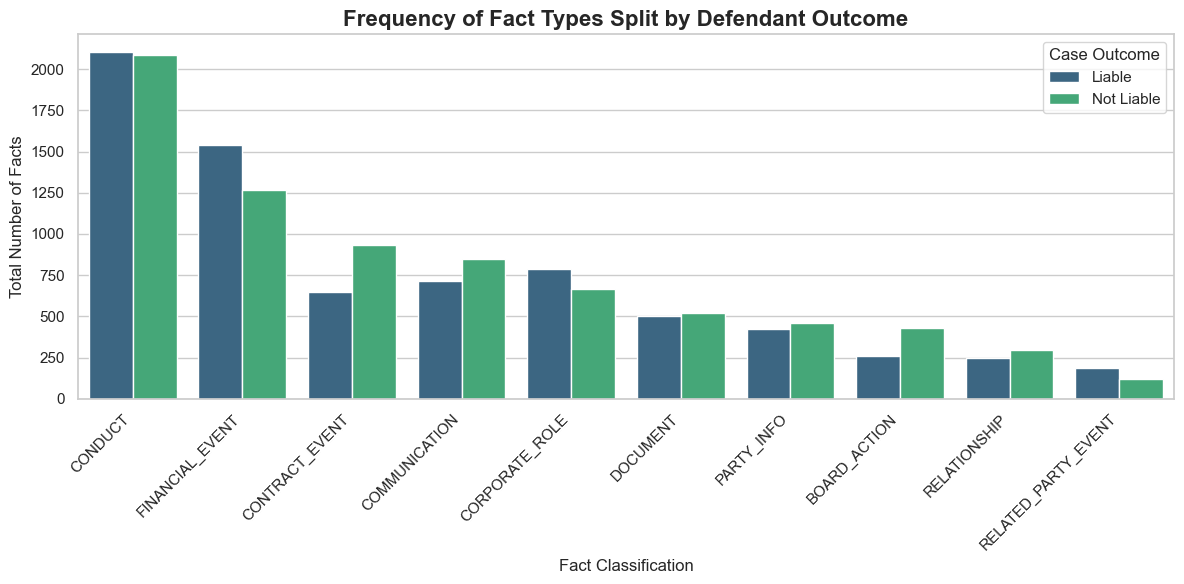

In [26]:
# 1. Create a master list to hold our unpacked facts
extracted_facts = []

# 2. Iterate through every row in your flattened DataFrame
for index, row in df.iterrows():
    # Let's split by the defendant's label (you can change this to plaintiff_label)
    outcome_label = row['defendant_label'] 
    
    cell = row['Combined_Facts']
    
    # Safely evaluate if the data was stringified by a CSV export
    if isinstance(cell, str):
        try:
            cell = ast.literal_eval(cell)
        except (ValueError, SyntaxError):
            continue
            
    # cell is expected to be: [ [Plaintiff Facts], [Defendant Facts] ]
    if isinstance(cell, list):
        for party_facts in cell:
            if isinstance(party_facts, list):
                for fact in party_facts:
                    # Look for the dictionaries that contain the actual fact data
                    if isinstance(fact, dict) and 'Fact_Type' in fact:
                        extracted_facts.append({
                            'Fact_Type': fact['Fact_Type'],
                            'Outcome_Label': outcome_label
                        })

# 3. Convert the list of dictionaries into a new Pandas DataFrame
df_facts_expanded = pd.DataFrame(extracted_facts)

# 4. Group by the Fact_Type and the Outcome_Label to get the counts
fact_counts = df_facts_expanded.groupby(['Fact_Type', 'Outcome_Label']).size().reset_index(name='Count')

# Sort it so it looks nice in the printout
fact_counts = fact_counts.sort_values(by=['Count'], ascending=False)
print("--- Tabular Breakdown ---")
print(fact_counts.to_string(index=False))

# 5. Visualize it!
plt.figure(figsize=(12, 6))

# Use seaborn's grouped bar chart functionality via the 'hue' parameter
sns.barplot(
    data=fact_counts, 
    x='Fact_Type', 
    y='Count', 
    hue='Outcome_Label', 
    palette='viridis'
)

plt.title('Frequency of Fact Types Split by Defendant Outcome', fontsize=16, fontweight='bold')
plt.xlabel('Fact Classification', fontsize=12)
plt.ylabel('Total Number of Facts', fontsize=12)
plt.xticks(rotation=45, ha='right') # Rotate labels so they don't overlap
plt.legend(title='Case Outcome')
plt.tight_layout()
plt.show()

--- Tabular Data: Outcomes by P:D Ratio ---
P:D Ratio defendant_label  Total Combinations
      1:1          Liable                  26
      1:1      Not Liable                  16
     1:10          Liable                   2
     1:10      Not Liable                   8
      1:2          Liable                  37
      1:2      Not Liable                  25
      1:3          Liable                  37
      1:3      Not Liable                  41
      1:4          Liable                   9
      1:4      Not Liable                   7
      1:5          Liable                   4
      1:5      Not Liable                  16
      1:6          Liable                  13
      1:6      Not Liable                  11
      1:7          Liable                   6
      1:7      Not Liable                   8
      1:8          Liable                   4
      1:8      Not Liable                   4
      1:9      Not Liable                   9
      2:1          Liable           

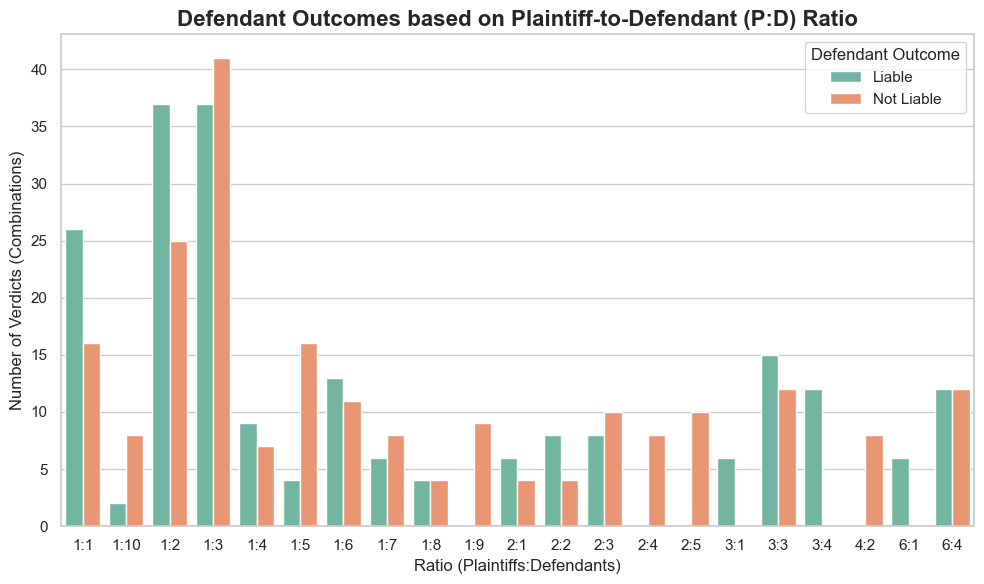

In [28]:
# 1. Calculate the number of unique Plaintiffs and Defendants per Case
case_summary = df.groupby('Case_Number').agg(
    Num_Plaintiffs=('Plaintiff_Name', 'nunique'),
    Num_Defendants=('Defendant_Name', 'nunique')
).reset_index()

# 2. Create the numerical ratio string (e.g., "3:1" instead of "3P : 1D")
case_summary['P:D Ratio'] = case_summary['Num_Plaintiffs'].astype(str) + ":" + case_summary['Num_Defendants'].astype(str)

# 3. Merge this ratio back into our main working DataFrame
if 'P:D Ratio' in df.columns:
    df = df.drop(columns=['P:D Ratio']) # Drop if it already exists from a previous run
df = df.merge(case_summary[['Case_Number', 'P:D Ratio']], on='Case_Number', how='left')

# 4. Group by the Ratio and the Outcome Label to count them
ratio_outcome_counts = df.groupby(['P:D Ratio', 'defendant_label']).size().reset_index(name='Total Combinations')

print("--- Tabular Data: Outcomes by P:D Ratio ---")
print(ratio_outcome_counts.to_string(index=False))
print("\n")

# 5. Visualize it!
plt.figure(figsize=(10, 6))

sns.barplot(
    data=ratio_outcome_counts, 
    x='P:D Ratio', 
    y='Total Combinations', 
    hue='defendant_label', 
    palette='Set2'
)

plt.title('Defendant Outcomes based on Plaintiff-to-Defendant (P:D) Ratio', fontsize=16, fontweight='bold')
plt.xlabel('Ratio (Plaintiffs:Defendants)', fontsize=12)
plt.ylabel('Number of Verdicts (Combinations)', fontsize=12)
plt.legend(title='Defendant Outcome')
plt.tight_layout()
plt.show()

Extracting text using fast regex method...
Text extraction complete!


C:\Users\User\AppData\Local\Temp\ipykernel_36884\2185294624.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_words, x='Count', y='Word', ax=axes[i], palette='magma')
C:\Users\User\AppData\Local\Temp\ipykernel_36884\2185294624.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_words, x='Count', y='Word', ax=axes[i], palette='magma')


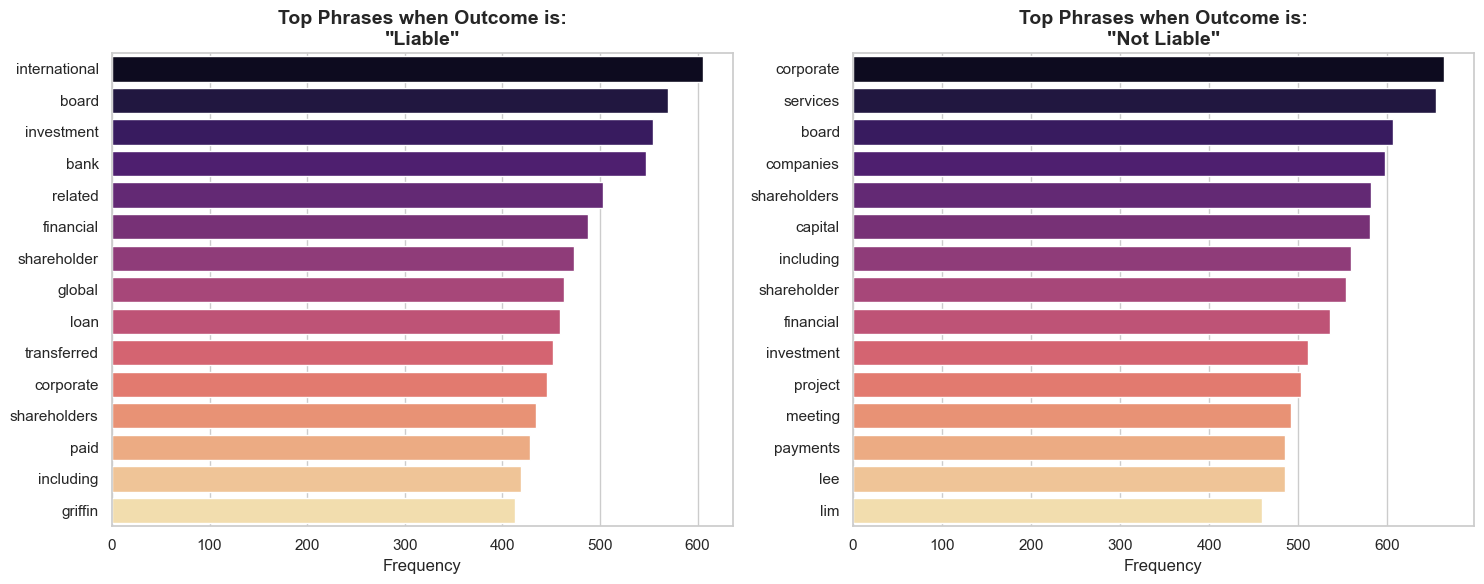

In [40]:
import pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer, ENGLISH_STOP_WORDS

def fast_extract_text(row):
    text_blocks = []
    for col in ['Combined_Facts', 'Combined_Issue', 'Combined_Rule', 'Combined_Application']:
        cell = str(row[col])
        
        dict_texts = re.findall(r"['\"]Text['\"]\s*:\s*['\"](.*?)['\"](?=\s*[,}])", cell)
        
        if dict_texts:
            text_blocks.extend(dict_texts)
        else:
            clean_text = re.sub(r"[\[\]{}'\"]", " ", cell)
            text_blocks.append(clean_text)
            
    return " ".join(text_blocks)

print("Extracting text using fast regex method...")
df['Full_Case_Text'] = df.apply(fast_extract_text, axis=1)
print("Text extraction complete!")

months = [
    'january', 'february', 'march', 'april', 'may', 'june', 
    'july', 'august', 'september', 'october', 'november', 'december'
]

# Existing legal boilerplate words
custom_legal_stopwords = [
    'pte', 'ltd', 'company', 'plaintiff', 'defendant', 'director', 'directors',
    'mr', 'ms', 'group', 'limited', 'singapore', 'holdings', 'shares',
    'account', 'business', 'agreement', 'management', 'court', 'case', 'claim',
    'said', 'stated'
]

# Combine English stop words + legal words + months
all_stop_words = list(ENGLISH_STOP_WORDS) + custom_legal_stopwords + months

# The token_pattern still strictly enforces letters only (no numbers)
vectorizer = CountVectorizer(
    stop_words=all_stop_words, 
    ngram_range=(1, 2),
    token_pattern=r"(?u)\b[a-zA-Z]{2,}\b"
)

outcomes = df['defendant_label'].dropna().unique()

fig, axes = plt.subplots(1, len(outcomes), figsize=(15, 6), sharey=False)
if len(outcomes) == 1: 
    axes = [axes] # Failsafe if there is only 1 outcome

for i, outcome in enumerate(outcomes):
    subset_text = df[df['defendant_label'] == outcome]['Full_Case_Text']
    
    if subset_text.empty:
        continue
        
    word_counts = vectorizer.fit_transform(subset_text)
    words = vectorizer.get_feature_names_out()
    counts = word_counts.sum(axis=0).A1 
    
    df_words = pd.DataFrame({'Word': words, 'Count': counts})
    df_words = df_words.sort_values('Count', ascending=False).head(15)
    
    # Plot 
    sns.barplot(data=df_words, x='Count', y='Word', ax=axes[i], palette='magma')
    axes[i].set_title(f'Top Phrases when Outcome is:\n"{outcome}"', fontsize=14, fontweight='bold')
    axes[i].set_xlabel('Frequency')
    axes[i].set_ylabel('')

plt.tight_layout()
plt.show()